In [1]:
%pip install --quiet -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


## Setup

In [2]:
import os
import random
import numpy as np
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from utils.hunt_data_loader import HuntDataLoader
from utils.train_eval import build_optimizer, fit_2D
from utils.loss_functions import vae_loss
from models.alzheimers_cure_2d import VAE
from models.no_more_alzheimer_2d import UNet2D
from models.alzheiminator_3d import ResidualUNet3D

data_loader = HuntDataLoader()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
training_pairs, test_pairs = data_loader.split_training_test_paths(seed=69)
print("We have", len(training_pairs), "training pairs")
print("We have", len(test_pairs), "test pairs")

We have 562 training pairs
We have 141 test pairs


Display the middle slice of the dataset

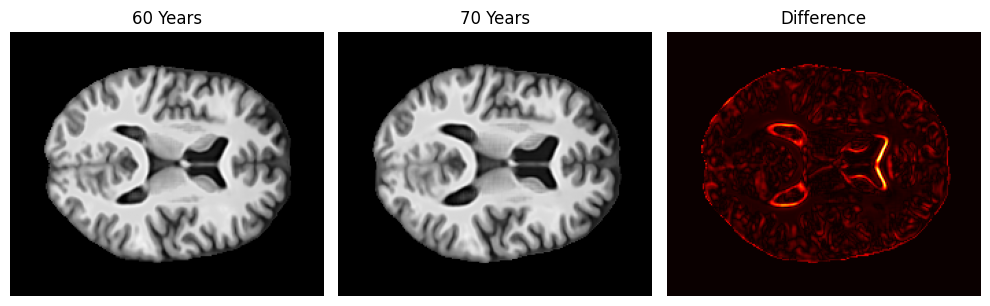

In [4]:
middle_h3 = data_loader.get_slice(training_pairs[100][0], index=90)
middle_h4 = data_loader.get_slice(training_pairs[100][1], index=90)

difference = np.abs(middle_h3 - middle_h4)
data_loader.display_slices([middle_h3, middle_h4, difference], ["60 Years", "70 Years", "Difference"], slice_colors=["gray", "gray", "hot"])

## One model for whole brain

In [5]:
# Load VAE and optimizer
vae = VAE(latent_dim=64).to(device)
vae_optimizer = build_optimizer(vae, lr=1e-4, wd=1e-4)

# Load UNET and optimizer
unet = UNet2D(latent_dim=64, in_channels=1, out_channels=1, base_ch=32).to(device)
unet_optimizer = build_optimizer(unet, lr=1e-4, wd=1e-4)

In [ ]:
_, vae_snapshots = fit_2D(vae, 
                            device,
                            data_loader,
                            training_pairs, 
                            vae_loss, 
                            optimizer=vae_optimizer, 
                            epochs=1001, 
                            print_every=200, 
                            save_every=200,
                            )

Saved snapshot for pair 0 at slice idx 90


In [ ]:
_, unet_snapshots = fit_2D(unet, 
                            device,
                            data_loader,
                            training_pairs, 
                            vae_loss, 
                            optimizer=unet_optimizer, 
                            epochs=1001, 
                            print_every=200, 
                            save_every=200,
                            )

Saved snapshot for pair 0 at slice idx 90
Saved snapshot for pair 10 at slice idx 90
Saved snapshot for pair 20 at slice idx 90
Saved snapshot for pair 30 at slice idx 90
Saved snapshot for pair 40 at slice idx 90
Saved snapshot for pair 50 at slice idx 90
Saved snapshot for pair 60 at slice idx 90
Saved snapshot for pair 70 at slice idx 90
Saved snapshot for pair 80 at slice idx 90
Saved snapshot for pair 90 at slice idx 90
Saved snapshot for pair 100 at slice idx 90


Displaying comparison snapshot from pair 0


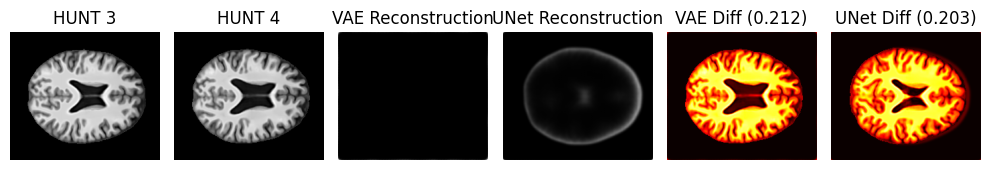

Displaying comparison snapshot from pair 10


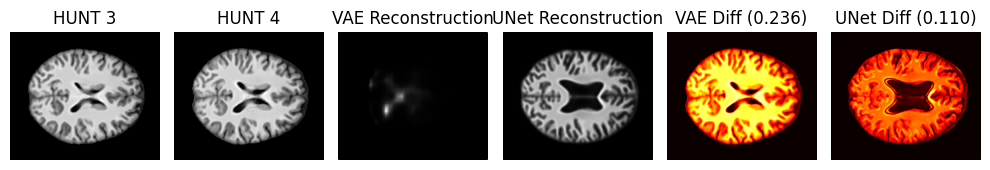

Displaying comparison snapshot from pair 20


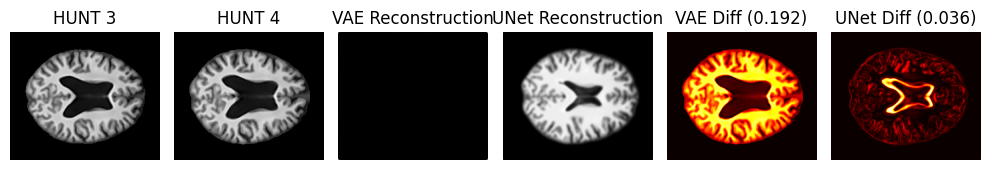

Displaying comparison snapshot from pair 30


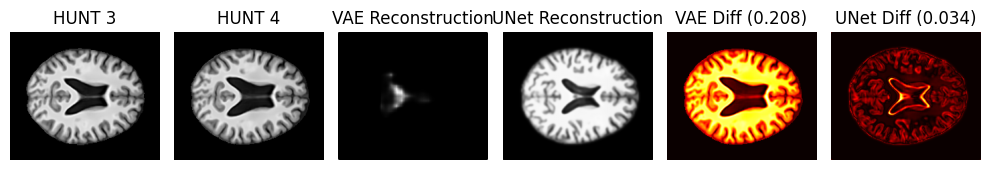

Displaying comparison snapshot from pair 40


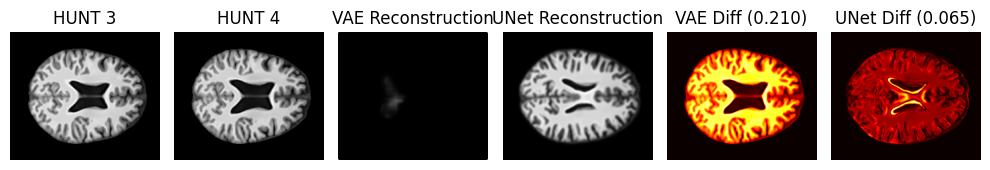

Displaying comparison snapshot from pair 50


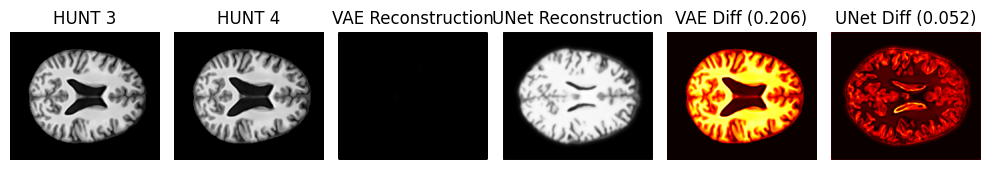

Displaying comparison snapshot from pair 60


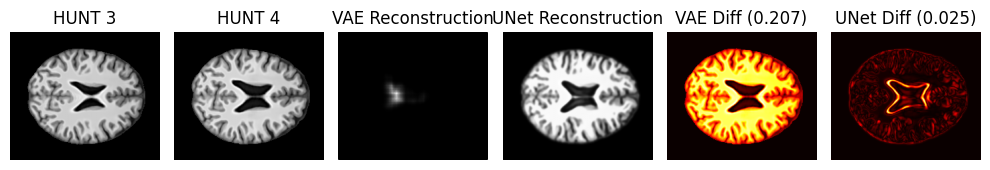

Displaying comparison snapshot from pair 70


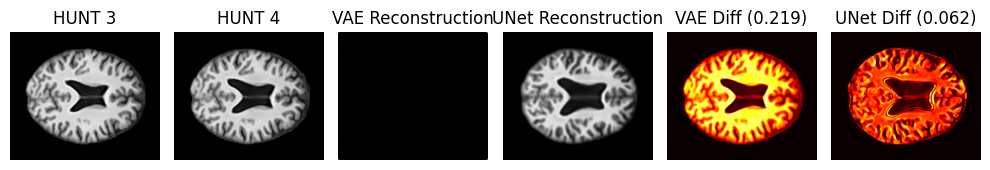

Displaying comparison snapshot from pair 80


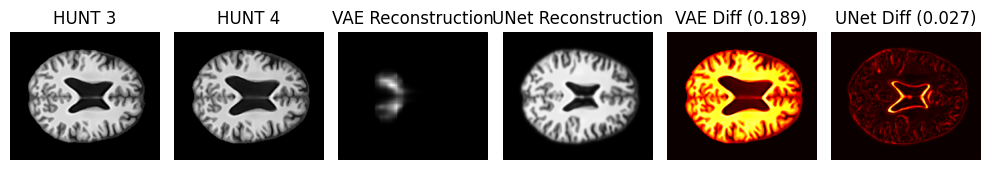

Displaying comparison snapshot from pair 90


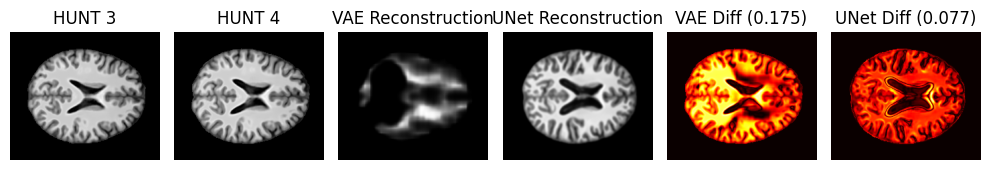

Displaying comparison snapshot from pair 100


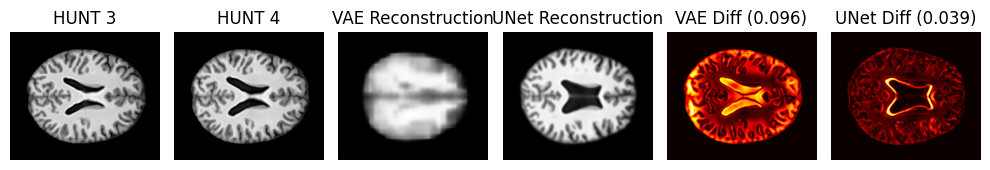

In [ ]:
for vae_snap, unet_snap in zip(vae_snapshots, unet_snapshots):
    iter = vae_snap["iter"] # Both have the same iter so doesn't matter
    print(f"Displaying comparison snapshot from pair {iter}")

    # Compute differences
    vae_diff = np.abs(vae_snap["recon"] - vae_snap["y"])
    unet_diff = np.abs(unet_snap["recon"] - unet_snap["y"])

    # Prepare visualization
    slices = [
        vae_snap["x"],          # HUNT 3
        vae_snap["y"],          # HUNT 4
        vae_snap["recon"],      # VAE Reconstruction
        unet_snap["recon"],     # UNet Reconstruction
        vae_diff,               # VAE Diff
        unet_diff               # UNet Diff
    ]
    labels = [
        "HUNT 3",
        "HUNT 4",
        "VAE Reconstruction",
        "UNet Reconstruction",
        # The Diff value here is a very simple mean error indication
        f"VAE Diff ({np.mean(vae_diff):.3f})", 
        f"UNet Diff ({np.mean(unet_diff):.3f})"
    ]

    data_loader.display_slices(slices, slice_labels=labels, slice_colors=["gray", "gray", "gray", "gray", "hot", "hot"])


## One model per Slice Index